In [1]:
import numpy as np
import matplotlib.pyplot as plt

def complex_function(x_vals, m, k, Delta):
    """
    Computes the function sum_{j=0}^{m-1} exp(2pi i j k / m) * sum_{l=-inf}^{inf} exp(-pi (x - j - ml)^2 / Delta^2)
    """
    # We approximate the infinite sum over l.
    # Since the Gaussian decays, we only need l such that |x - j - ml| is within some range of Delta.
    # Let's take a generous range for l.
    
    result = np.zeros_like(x_vals, dtype=np.complex128)
    
    # Range of l: large enough to cover typical plot ranges
    l_range = np.arange(-20, 21)
    
    for j in range(m):
        # Phase factor for this j
        phase = np.exp(2 * np.pi * 1j * j * k / m)
        
        # Inner sum over l
        inner_sum = np.zeros_like(x_vals, dtype=np.float64)
        for l in l_range:
            # Argument of the Gaussian
            arg = (x_vals - j - m * l)**2
            term = np.exp(-np.pi * arg / (Delta**2))
            inner_sum += term
            
        result += phase * inner_sum
        
    return result

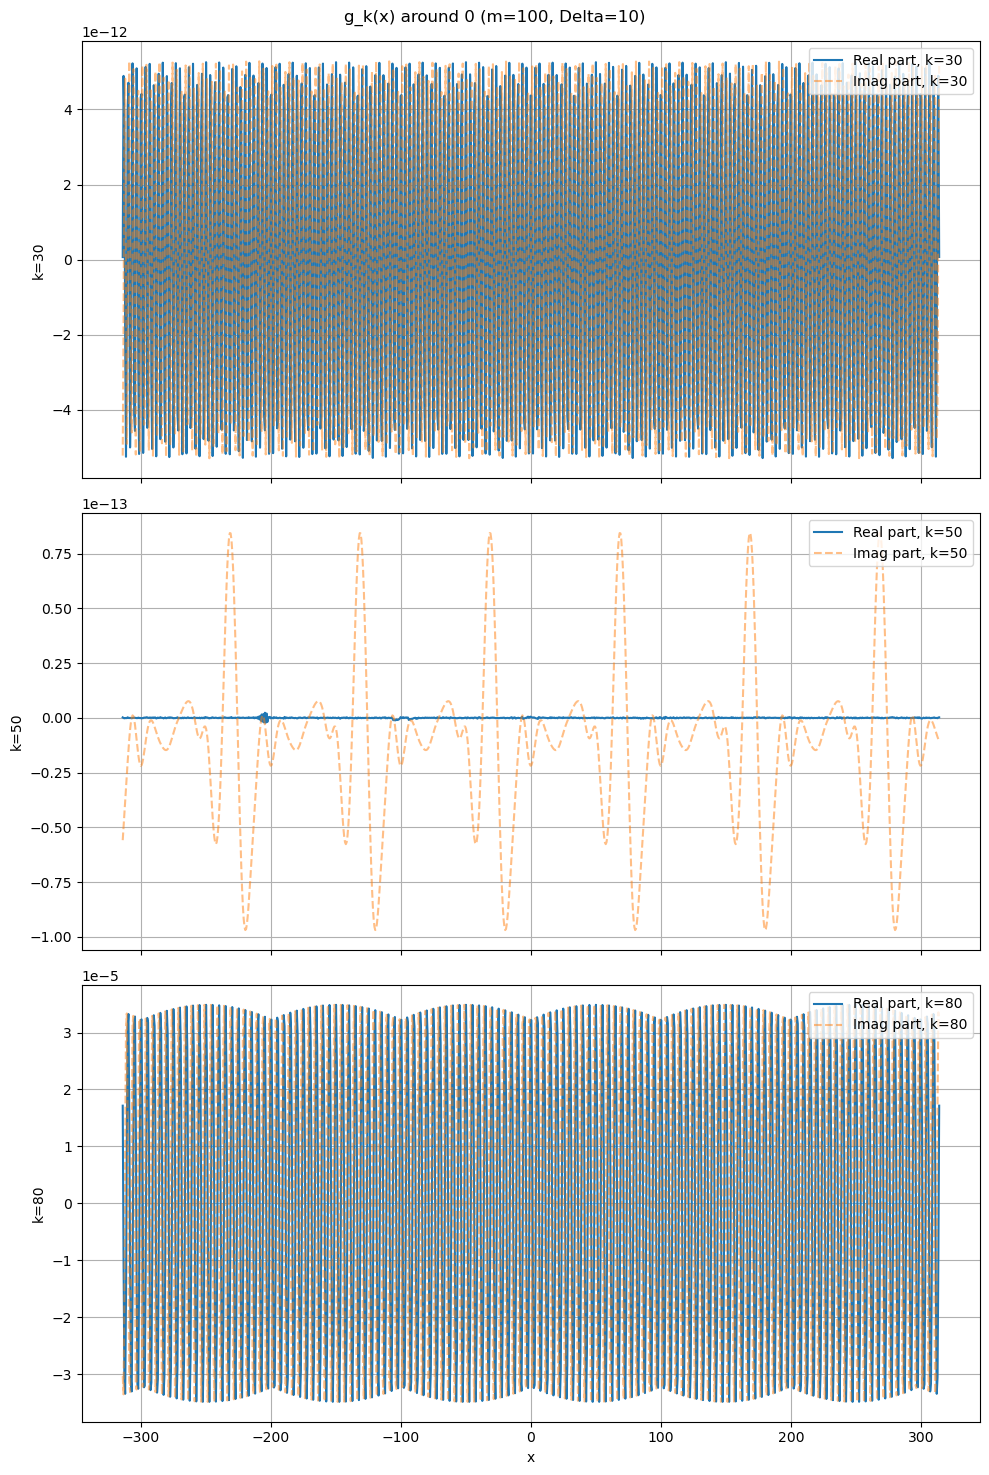

In [9]:
# Parameters
m = 100
Delta = 10
k_values = [30,50,80]
x = 2*np.pi*np.linspace(-50, 50, 1000)

# Plotting
fig, axes = plt.subplots(len(k_values), 1, figsize=(10, 15), sharex=True)
if len(k_values) == 1:
    axes = [axes]

for idx, k in enumerate(k_values):
    y = complex_function(x, m, k, Delta)
    ax = axes[idx]
    ax.plot(x, y.real, label=f'Real part, k={k}')
    ax.plot(x, y.imag, '--', alpha=0.5, label=f'Imag part, k={k}')
    ax.set_ylabel(f'k={k}')
    ax.legend(loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('x')
plt.suptitle(f'g_k(x) around 0 (m={m}, Delta={Delta})')
plt.tight_layout()
plt.show()